Iteration 10/1000, Average Rewards: [0.21469137920123904, 0.19280290105134262]


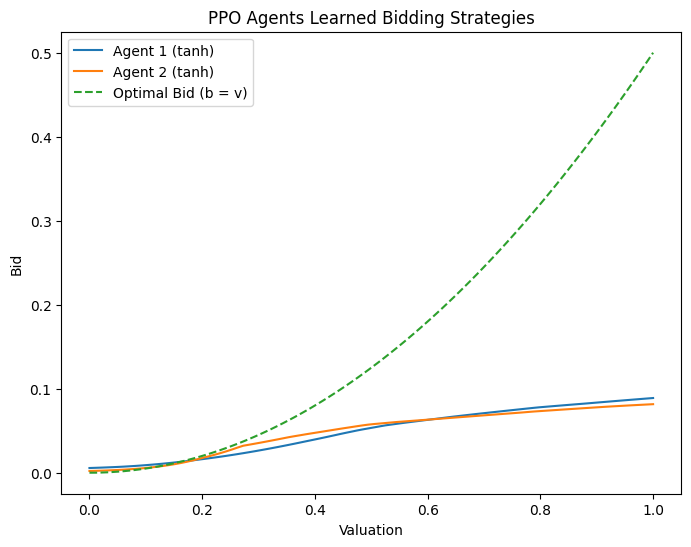

Iteration 20/1000, Average Rewards: [0.18080675625053114, 0.17437575436345243]


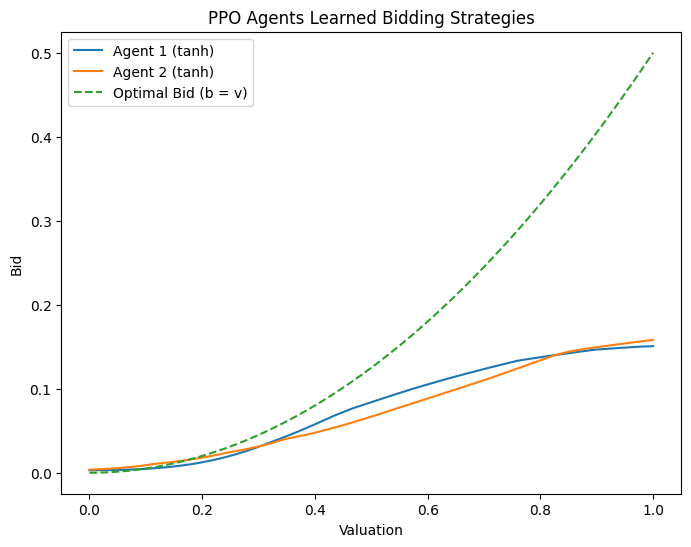

Iteration 30/1000, Average Rewards: [0.17056237352788223, 0.19476656208526422]


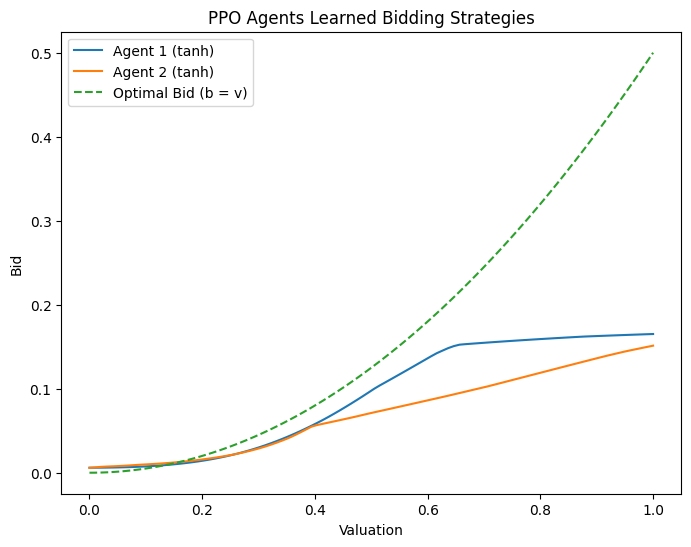

Iteration 40/1000, Average Rewards: [0.17980032545940397, 0.11996219349400492]


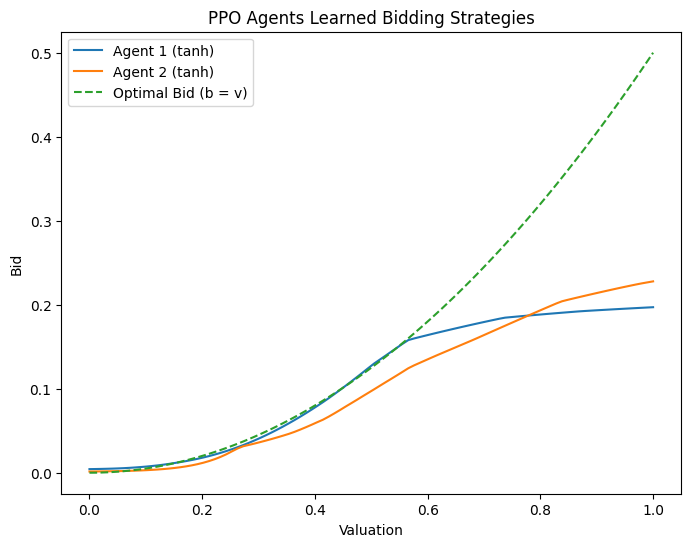

Iteration 50/1000, Average Rewards: [0.13343077439756795, 0.15466884047108082]


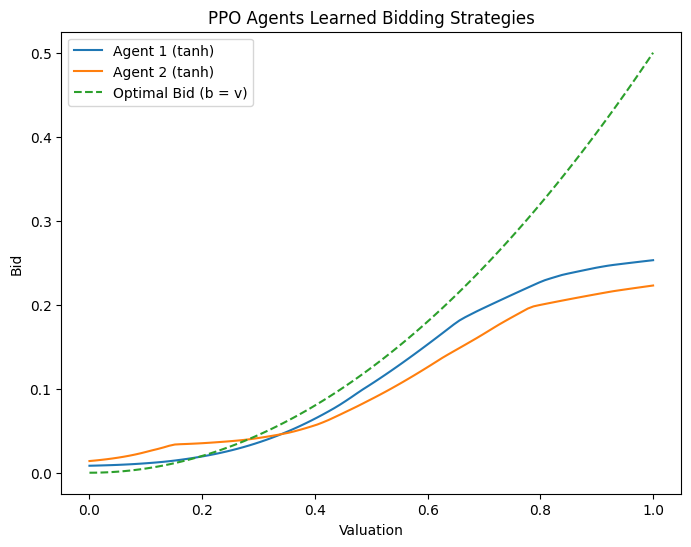

Iteration 60/1000, Average Rewards: [0.18109996986600607, 0.16559840980877255]


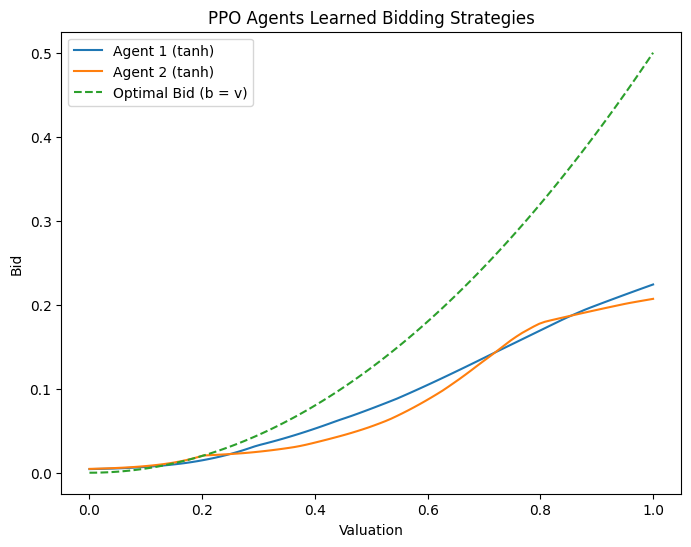

Iteration 70/1000, Average Rewards: [0.19707306345891207, 0.1611798474102795]


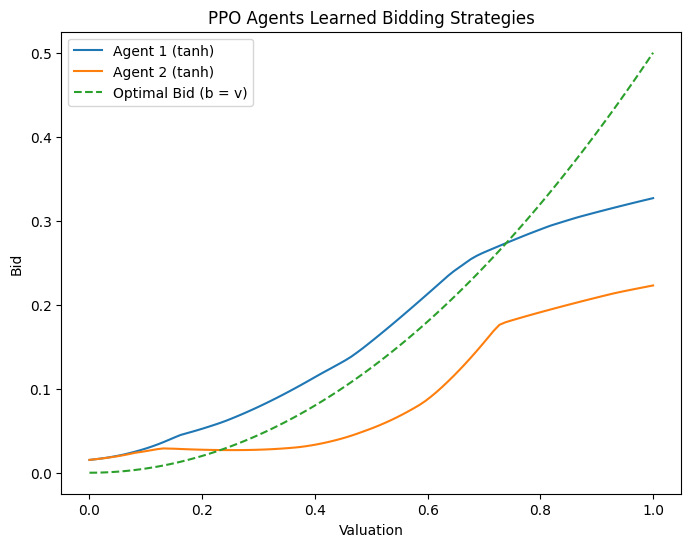

Iteration 80/1000, Average Rewards: [0.12054460508655432, 0.1145588151462972]


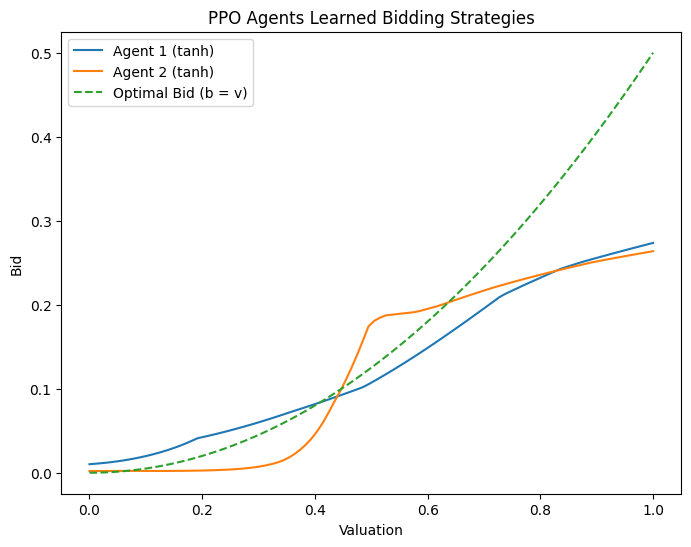

Iteration 90/1000, Average Rewards: [-0.12516804379976526, -0.04602361143387208]


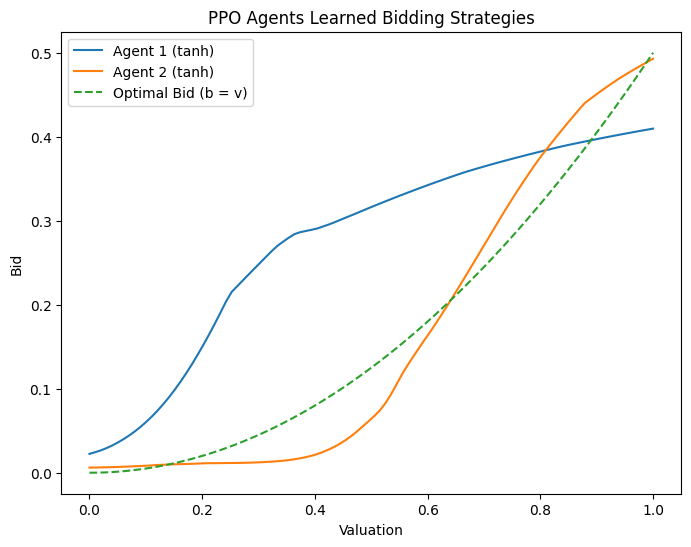

Iteration 100/1000, Average Rewards: [-0.033742999209761024, -0.020753419897229293]


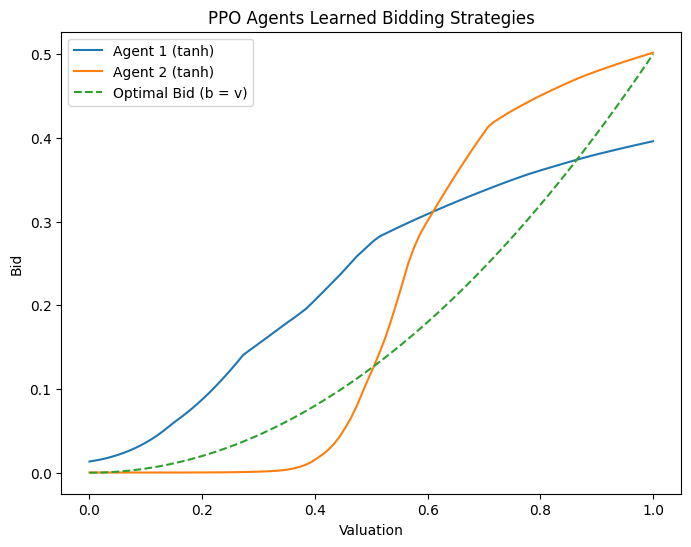

Iteration 110/1000, Average Rewards: [0.0504924789356052, 0.06495097318948675]


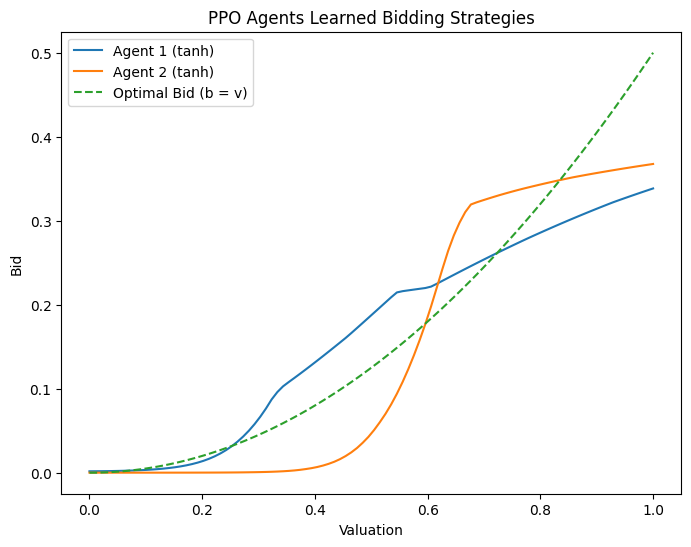

Iteration 120/1000, Average Rewards: [0.04649710600098475, 0.04713399272500246]


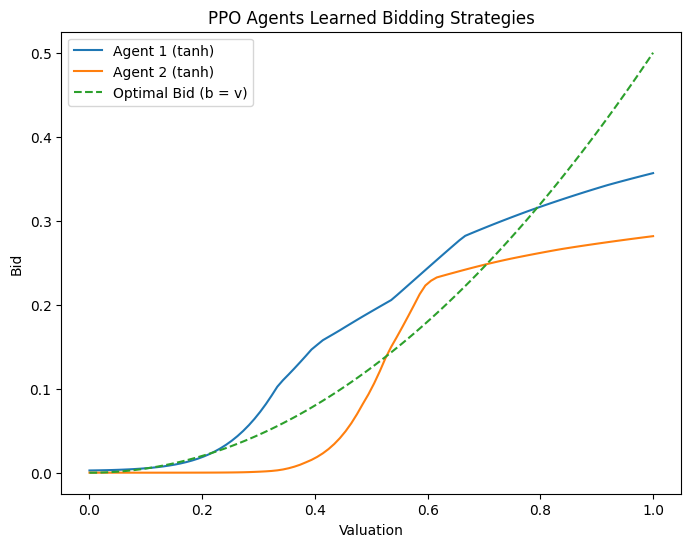

Iteration 130/1000, Average Rewards: [0.16339421670726764, 0.08526301485280324]


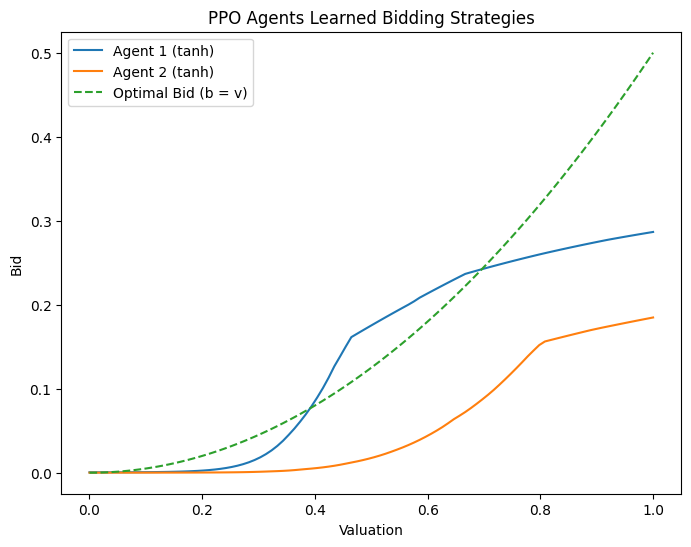

Iteration 140/1000, Average Rewards: [0.1269718893326335, 0.09705608579275783]


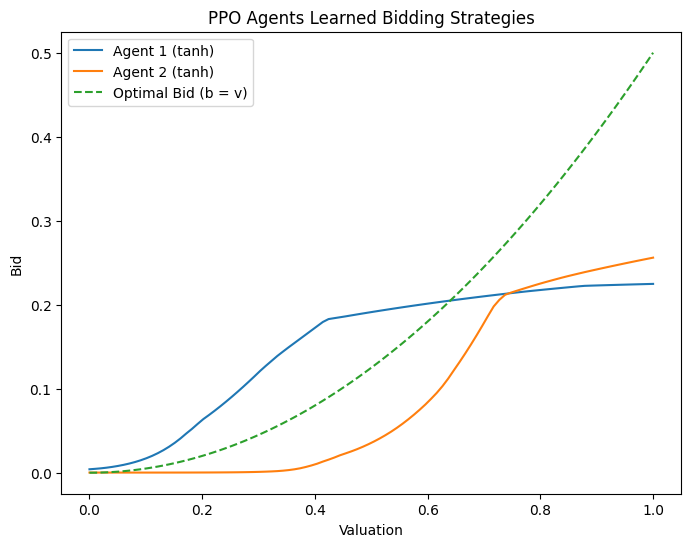

Iteration 150/1000, Average Rewards: [0.16716196372222986, 0.16782596843864434]


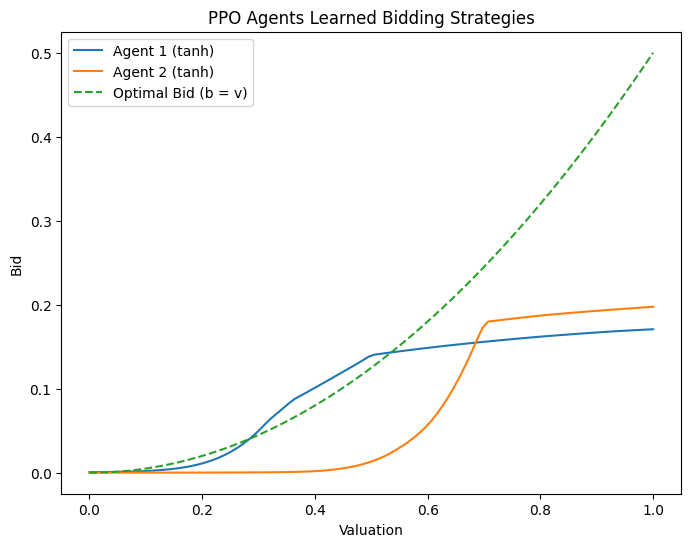

Iteration 160/1000, Average Rewards: [0.12448392867981857, 0.277891577653929]


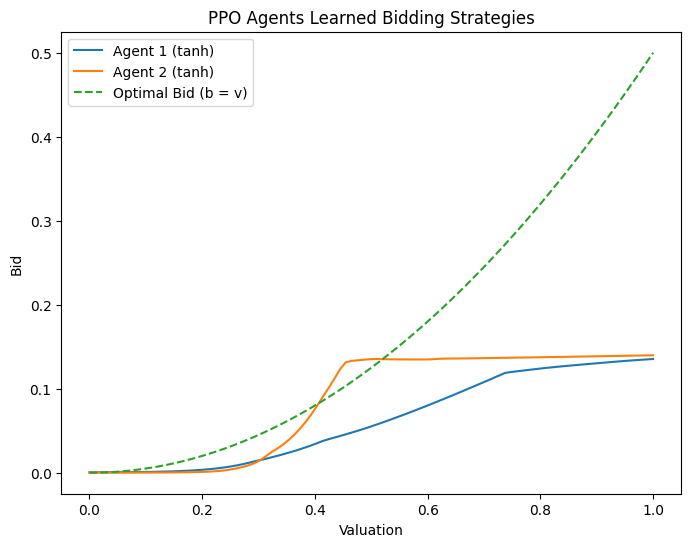

Iteration 170/1000, Average Rewards: [0.21914652260371315, 0.22998511484333448]


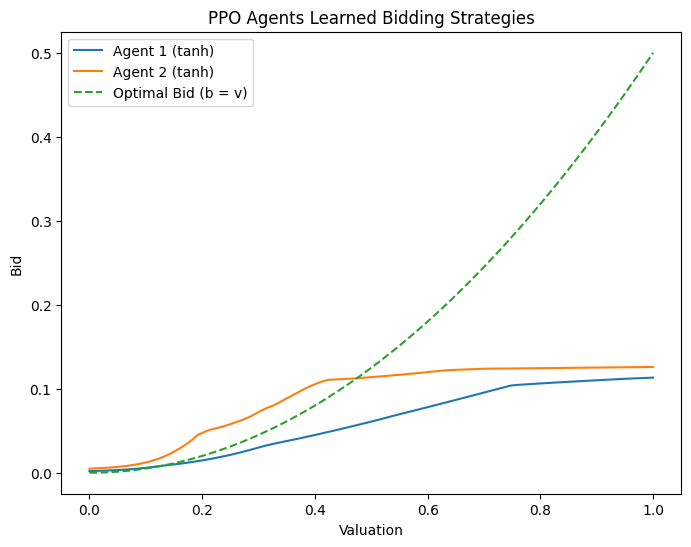

Iteration 180/1000, Average Rewards: [0.19782971994329016, 0.23065016610011632]


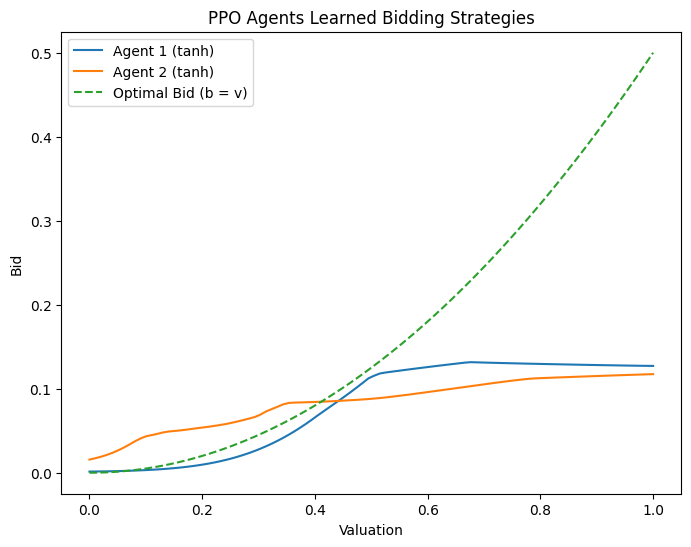

Iteration 190/1000, Average Rewards: [0.1581144057981313, 0.27852075040402796]


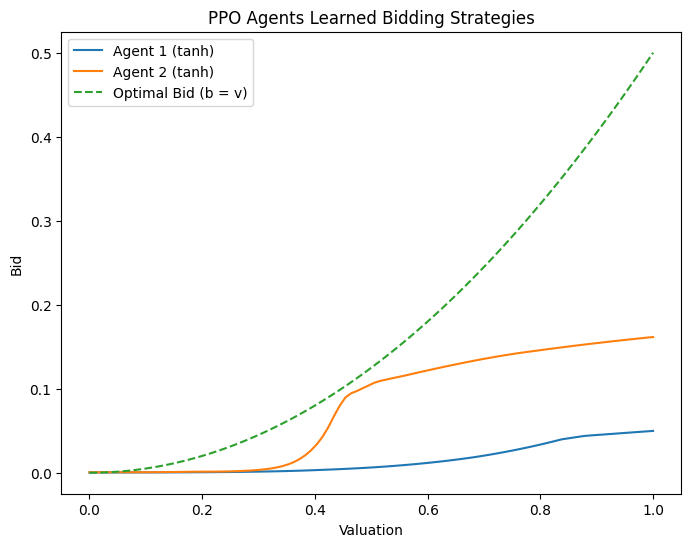

Iteration 200/1000, Average Rewards: [0.14394166380052076, 0.47178234716280487]


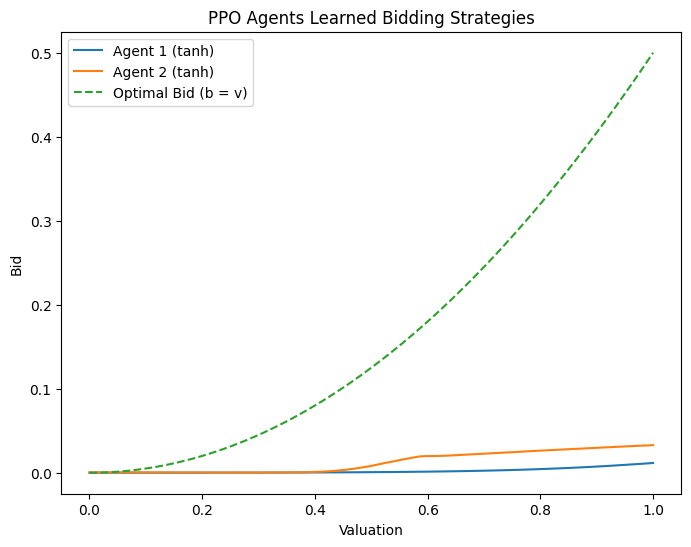

Iteration 210/1000, Average Rewards: [0.16351572833635758, 0.43609225028216075]


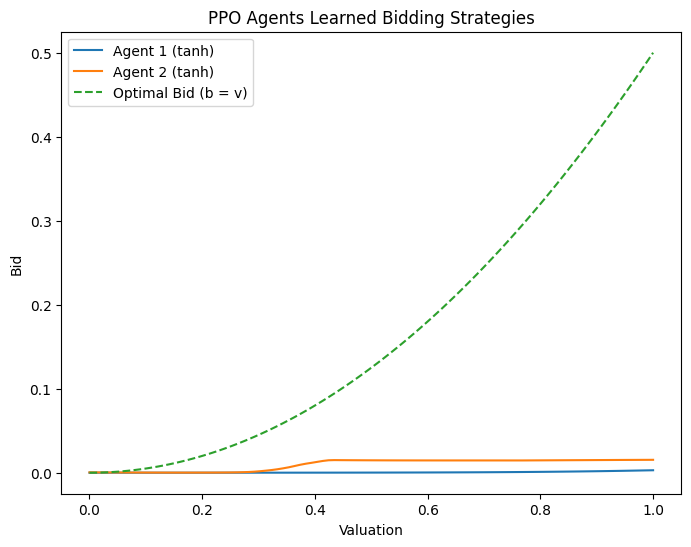

Iteration 220/1000, Average Rewards: [0.14418493785576147, 0.4515859407440477]


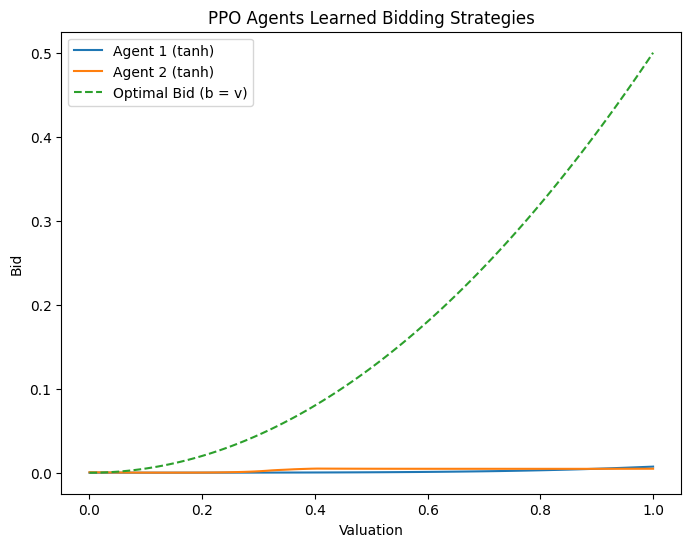

Iteration 230/1000, Average Rewards: [0.47153290521314084, 0.08624571515171299]


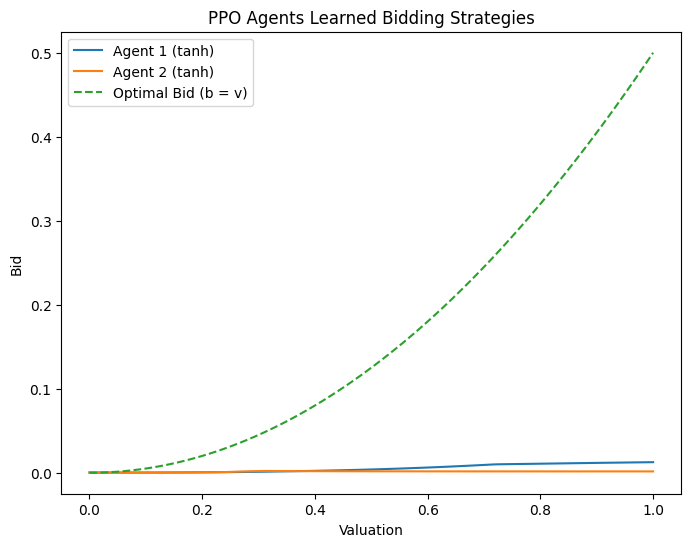

Iteration 240/1000, Average Rewards: [0.4178580795813234, 0.18892139507869654]


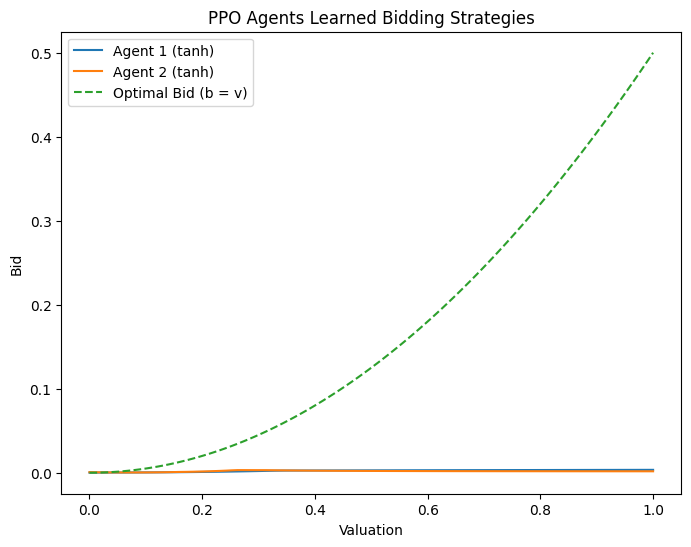

Iteration 250/1000, Average Rewards: [0.47928410324200743, -0.0027146410720888525]


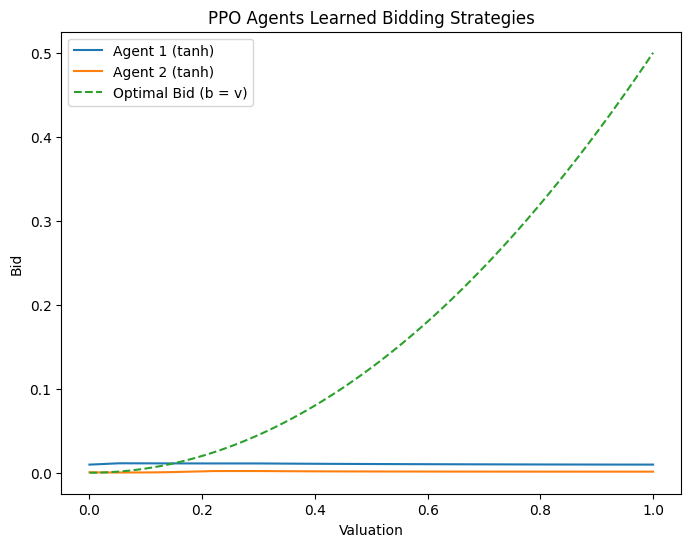

Iteration 260/1000, Average Rewards: [0.5058738194424115, 0.02309866535380348]


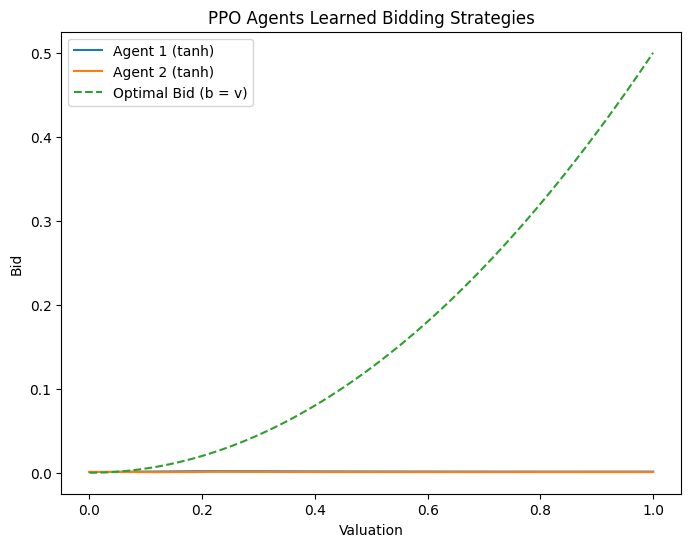

Iteration 270/1000, Average Rewards: [0.001258727465607848, 0.5101226657223453]


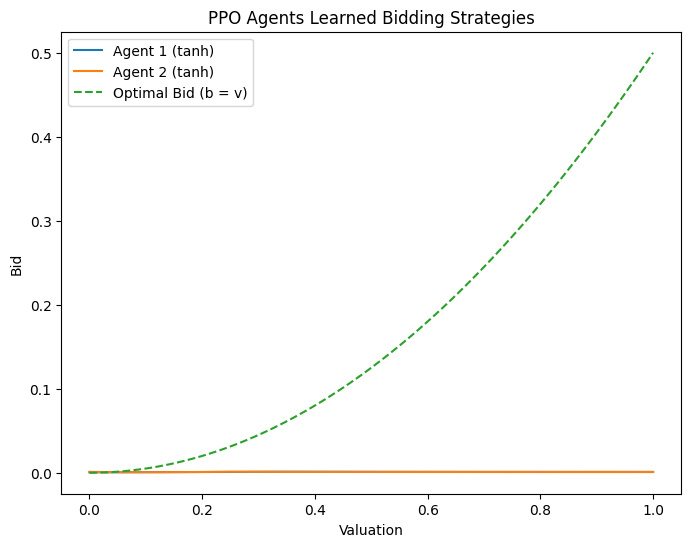

Iteration 280/1000, Average Rewards: [0.029292103343240547, 0.4510704786458783]


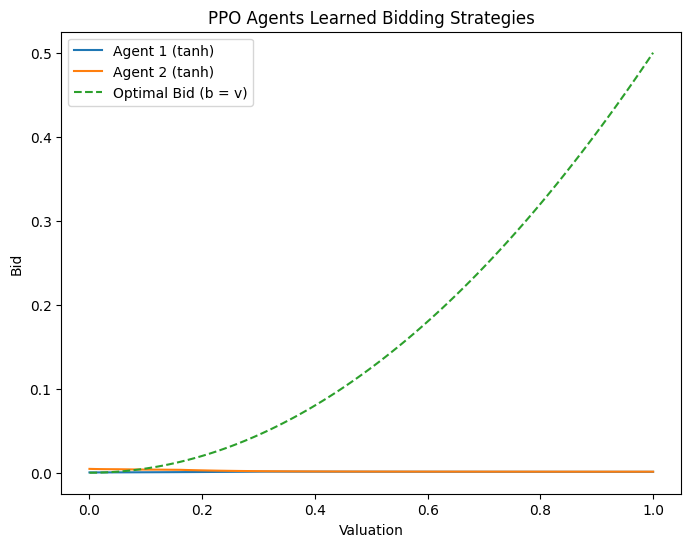

Iteration 290/1000, Average Rewards: [0.3865438549362398, 0.016765647273668867]


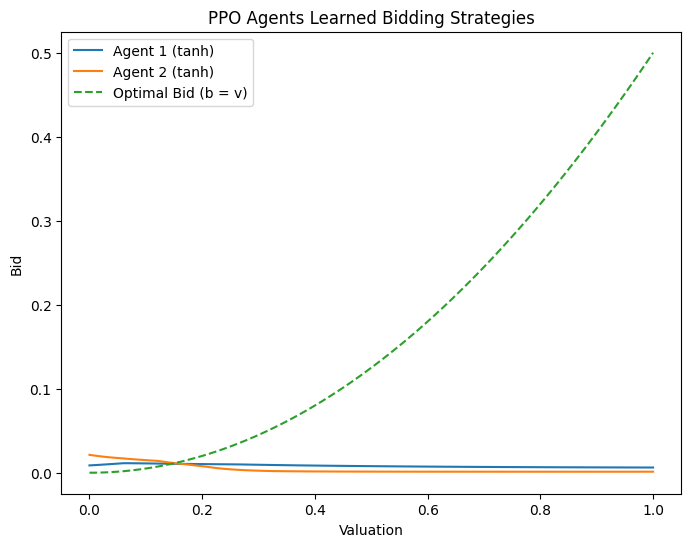

Iteration 300/1000, Average Rewards: [0.4851195332919654, -0.001982495707397178]


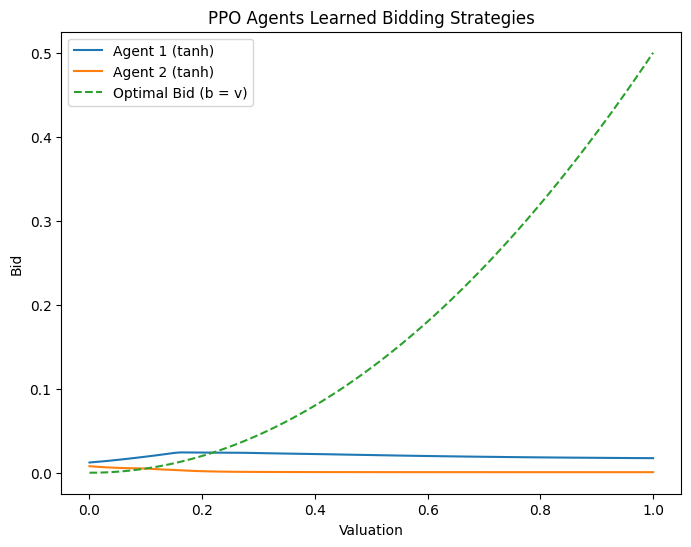

Iteration 310/1000, Average Rewards: [0.4928487749667893, -0.00044939338113181293]


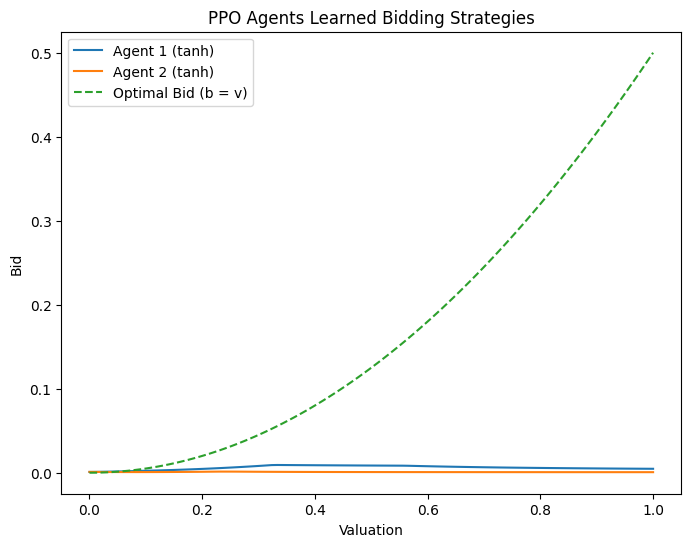

Iteration 320/1000, Average Rewards: [0.49399210717349645, -0.0006625504174735397]


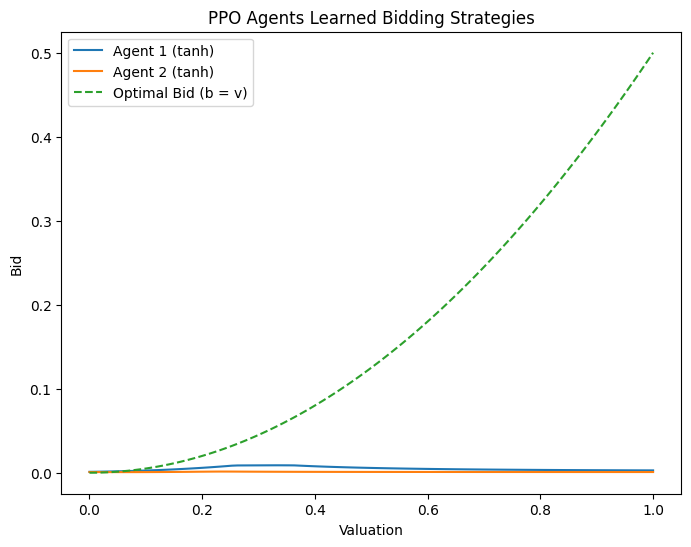

Iteration 330/1000, Average Rewards: [0.4971552080179529, -0.0003318820090498775]


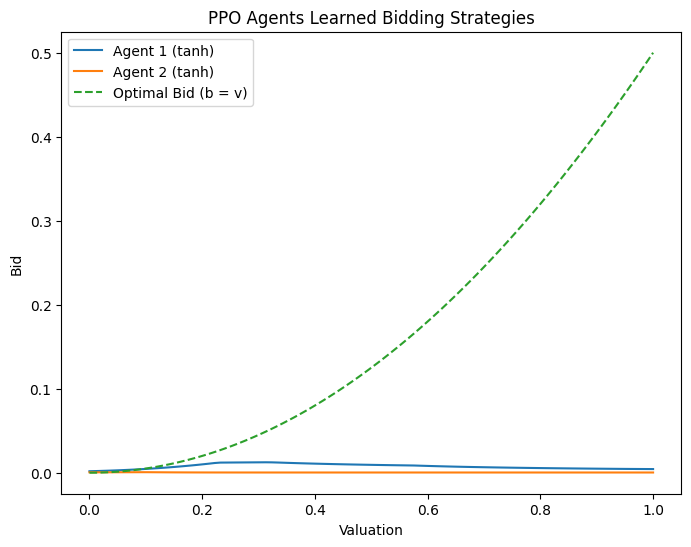

KeyboardInterrupt: 

In [34]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal
import gym
from gym import spaces
import matplotlib.pyplot as plt

# Set seed
seed = 12341234
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define the Auction Environment with Batch Support
class AuctionEnv(gym.Env):
    def __init__(self, num_agents=2, batch_size=1024, valuation_distribution=lambda size: np.random.uniform(0, 1, size=size), payment_rule='first_price', k=2):
        super(AuctionEnv, self).__init__()
        self.num_agents = num_agents
        self.batch_size = batch_size
        self.k = k  # For k-th price auction
        self.observation_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        self.action_space = spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        self.valuation_distribution = valuation_distribution
        self.payment_rule = payment_rule  # 'first_price', 'second_price', 'all_pay', 'kth_price'
        self.reset()

    def reset(self):
        # Generate valuations for all agents in the batch
        self.valuations = self.valuation_distribution((self.batch_size, self.num_agents))  # Shape: (batch_size, num_agents)
        self.states = self.valuations.copy()
        return self.states

    def step(self, actions):
        # actions: array of shape (batch_size, num_agents)
        bids = np.clip(actions, 0.0, 1.0)  # Shape: (batch_size, num_agents)
        max_bids = np.max(bids, axis=1)  # Shape: (batch_size,)
        epsilon = 1e-6
        is_max_bid = np.isclose(bids, max_bids[:, None], atol=epsilon)

        rand_nums = np.random.rand(self.batch_size, self.num_agents)
        rand_nums = np.where(is_max_bid, rand_nums, -1)
        winners = np.argmax(rand_nums, axis=1)  # Shape: (batch_size,)

        # Determine payment based on the auction rule
        if self.payment_rule == 'first_price':
            payments = bids[np.arange(self.batch_size), winners]
        
        elif self.payment_rule == 'second_price':
            sorted_bids = np.sort(bids, axis=1)
            if self.num_agents > 1:
                payments = sorted_bids[:, -2]
            else:
                payments = np.zeros(self.batch_size)
        
        elif self.payment_rule == 'all_pay':
            # In all-pay auctions, all agents pay their bids, but only the winner receives the reward
            payments = bids
        
        elif self.payment_rule == 'kth_price':
            sorted_bids = np.sort(bids, axis=1)
            k_valid = min(self.k, self.num_agents)
            payments = sorted_bids[:, -k_valid]
        
        else:
            raise ValueError("Invalid payment rule")

        # Compute rewards
        rewards = np.zeros((self.batch_size, self.num_agents))
        
        if self.payment_rule == 'all_pay':
            # In all-pay auction, only the winner gets reward, others just pay their bids
            rewards[np.arange(self.batch_size), winners] = (self.valuations[np.arange(self.batch_size), winners] + 0.01 - payments[np.arange(self.batch_size), winners])
            rewards -= payments  # All agents pay their bids

        else:
            rewards[np.arange(self.batch_size), winners] = (
                self.valuations[np.arange(self.batch_size), winners] - payments + 0.01
            )

        done = True  # Single-step episode
        info = {'bids': bids, 'valuations': self.valuations, 'winners': winners}
        next_states = self.reset()
        return next_states, rewards, done, info

    def render(self, mode='human'):
        pass


# Define the PPO Agent
class PPOAgent:
    def __init__(self, observation_space, action_space, action_bound_method='tanh', lr=3e-4, entropy_coef=0.01):
        self.observation_space = observation_space
        self.action_space = action_space
        self.action_bound_method = action_bound_method
        self.lr = lr
        self.entropy_coef = entropy_coef

        self.actor = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, action_space.shape[0])
        ).to(device)
        self.critic = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.LayerNorm(64),
            nn.Linear(64, 1)
        ).to(device)
        self.log_std = nn.Parameter(torch.zeros(action_space.shape[0]).to(device))

        self.optimizer = optim.Adam(self.parameters(), lr=self.lr)

    def parameters(self):
        return list(self.actor.parameters()) + list(self.critic.parameters()) + [self.log_std]

    def get_action(self, x):
        mean = self.actor(x)
        std = self.log_std.exp()
        normal = Normal(mean, std)
        if self.action_bound_method == 'tanh':
            # Sample from the normal distribution
            z = normal.rsample()
            # Apply tanh squashing
            action = torch.tanh(z)
            # Rescale action to [0,1]
            action = action * 0.5 + 0.5
            # Calculate log_prob using change of variables formula
            log_prob = normal.log_prob(z) - torch.log(1 - torch.tanh(z).pow(2) + 1e-6)
            log_prob = log_prob.sum(dim=-1)
            # Approximate entropy (using entropy of the base distribution)
            entropy = normal.entropy().sum(dim=-1)
        else:
            raise NotImplementedError("Only 'tanh' action_bound_method is implemented in this version.")
        return action, log_prob, entropy

    def get_value(self, x):
        return self.critic(x)

    def compute_loss(self, obs_batch, actions_batch, log_probs_old, returns, advantages, epsilon=0.2):
        mean = self.actor(obs_batch)
        std = self.log_std.exp()
        normal = Normal(mean, std)
        if self.action_bound_method == 'tanh':
            # Rescale actions to [-1,1]
            actions_bound = actions_batch * 2 - 1  # From [0,1] to [-1,1]
            # Atanh to get pre-squashed actions
            eps = 1e-6  # Small constant to avoid numerical issues
            actions_bound = torch.clamp(actions_bound, -1 + eps, 1 - eps)
            z = 0.5 * torch.log((1 + actions_bound) / (1 - actions_bound))
            # Calculate log_prob using change of variables formula
            log_probs = normal.log_prob(z) - torch.log(1 - actions_bound.pow(2) + eps)
            log_probs = log_probs.sum(dim=-1)
            # Approximate entropy
            entropy = normal.entropy().sum(dim=-1)
        else:
            raise NotImplementedError("Only 'tanh' action_bound_method is implemented in this version.")
        # Compute ratios
        ratios = torch.exp(log_probs - log_probs_old)
        # Surrogate loss
        surr1 = ratios * advantages
        surr2 = torch.clamp(ratios, 1 - epsilon, 1 + epsilon) * advantages
        actor_loss = -torch.min(surr1, surr2).mean()
        # Critic loss
        values = self.critic(obs_batch).squeeze()
        critic_loss = nn.MSELoss()(values, returns)
        # Total loss
        loss = actor_loss + 1.0 * critic_loss - self.entropy_coef * entropy.mean()
        return loss

    def update(self, loss):
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

def training_loop(num_iterations = 1000,  # Number of training iterations
                    batch_size = 1024,     # Number of auctions per iteration
                    learning_rate = 3e-4,  # learning rate
                    gamma = 0.0,          # Immediate reward only
                    epsilon = 0.25,         # PPO clipping epsilon
                    num_epochs = 10,       # PPO epochs, how many times to iterate on same data
                    num_minibatches = 32,  # Number of minibatches for PPO update
                    num_agents = 2,
                    env = AuctionEnv(num_agents=2, batch_size=1024, payment_rule='first_price'),  # Change to 'second_price' if needed
                    agents = None
                 ):

    for iteration in range(num_iterations):
        # Reset environment
        states = env.reset()  # Shape: (batch_size, num_agents)
    
        obs_batch = [[] for _ in range(num_agents)]
        actions_batch = [[] for _ in range(num_agents)]
        rewards_batch = [[] for _ in range(num_agents)]
        log_probs_batch = [[] for _ in range(num_agents)]
        values_batch = [[] for _ in range(num_agents)]
    
        # For each agent, process the batch
        for i in range(num_agents):
            obs = states[:, i]  # Shape: (batch_size,)
            obs_tensor = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(-1)  # Shape: (batch_size, 1)
            action, log_prob, entropy = agents[i].get_action(obs_tensor)
            value = agents[i].get_value(obs_tensor)
    
            # Store data
            obs_batch[i] = obs_tensor.cpu().numpy()
            actions_batch[i] = action.detach().cpu().numpy()
            log_probs_batch[i] = log_prob.detach().cpu().numpy()
            values_batch[i] = value.detach().cpu().numpy()
        
        # Stack actions to shape (batch_size, num_agents)
        actions = np.hstack([actions_batch[i] for i in range(num_agents)])  # Shape: (batch_size, num_agents)
    
        # Step environment with all actions
        next_states, rewards, done, _ = env.step(actions)
    
        # Store rewards
        for i in range(num_agents):
            rewards_batch[i] = rewards[:, i]
    
        # PPO Update for each agent
        for i in range(num_agents):
            obs_batch_i = torch.tensor(obs_batch[i], dtype=torch.float32, device=device)
            actions_batch_i = torch.tensor(actions_batch[i], dtype=torch.float32, device=device)
            rewards_batch_i = torch.tensor(rewards_batch[i], dtype=torch.float32, device=device)
            log_probs_batch_i = torch.tensor(log_probs_batch[i], dtype=torch.float32, device=device)
            values_batch_i = torch.tensor(values_batch[i], dtype=torch.float32, device=device).squeeze()
    
            # Compute Advantages and Returns
            returns = rewards_batch_i  # Since gamma=0, returns are immediate rewards
            advantages = returns - values_batch_i.detach()
    
            # Normalize Advantages
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    
            # PPO Update
            batch_indices = np.arange(batch_size)
            minibatch_size = batch_size // num_minibatches
            for _ in range(num_epochs):
                np.random.shuffle(batch_indices)
                for start in range(0, batch_size, minibatch_size):
                    end = start + minibatch_size
                    mb_inds = batch_indices[start:end]
    
                    mb_obs = obs_batch_i[mb_inds]
                    mb_actions = actions_batch_i[mb_inds]
                    mb_log_probs_old = log_probs_batch_i[mb_inds]
                    mb_advantages = advantages[mb_inds]
                    mb_returns = returns[mb_inds]
    
                    # Compute loss
                    loss = agents[i].compute_loss(
                        mb_obs, mb_actions, mb_log_probs_old, mb_returns, mb_advantages, epsilon
                    )
    
                    # Update agent
                    agents[i].update(loss)
    
        # Optional: Print progress
        if (iteration + 1) % 10 == 0:
            avg_rewards = [np.mean(rewards_batch[i]) for i in range(num_agents)]
            print(f"Iteration {iteration + 1}/{num_iterations}, Average Rewards: {avg_rewards}")
    
            # Plotting the Learned Bidding Functions
            valuations = np.linspace(0, 1, 100)
            bids_agents = [[] for _ in range(num_agents)]
            
            for v in valuations:
                obs_tensor = torch.tensor([[v]], dtype=torch.float32, device=device)
                for i in range(num_agents):
                    with torch.no_grad():
                        mean = agents[i].actor(obs_tensor)
                        std = agents[i].log_std.exp()
                        normal = Normal(mean, std)
                        z = normal.mean  # Use the mean action before squashing
                        action = torch.tanh(z)
                        action = action * 0.5 + 0.5  # Rescale to [0,1]
                        bid = action.cpu().numpy()[0][0]
                        bids_agents[i].append(bid)
            
            # Plot the bidding functions
            plt.figure(figsize=(8, 6))
            for i in range(num_agents):
                plt.plot(valuations, bids_agents[i], label=f'Agent {i+1} ({agents[i].action_bound_method})')
            # Plot the optimal bidding function
            optimal_bids = valuations**2/2  # For second-price auction, bidding truthfully
            plt.plot(valuations, optimal_bids, label='Optimal Bid (b = v)', linestyle='--')
            plt.xlabel('Valuation')
            plt.ylabel('Bid')
            plt.title('PPO Agents Learned Bidding Strategies')
            plt.legend()
            plt.show()


# Training Parameters
num_iterations = 1000  # Number of training iterations
batch_size = 1024     # Number of auctions per iteration
learning_rate = 3e-4
gamma = 0.0           # Immediate reward only
epsilon = 0.1         # PPO clipping epsilon
num_epochs = 10       # PPO epochs, how many times to iterate on same data
num_minibatches = 32  # Number of minibatches for PPO update

# Create Environment and Agents
num_agents = 2
env = AuctionEnv(num_agents=num_agents, batch_size=batch_size, payment_rule='all_pay')  # Change to 'second_price' if needed
agents = [
    PPOAgent(env.observation_space, env.action_space, action_bound_method='tanh', lr=learning_rate, entropy_coef=0.03),
    PPOAgent(env.observation_space, env.action_space, action_bound_method='tanh', lr=learning_rate, entropy_coef=0.03)
    #PPOAgent(env.observation_space, env.action_space, action_bound_method='tanh', lr=learning_rate, entropy_coef=0.01),
]

# Training Loop
training_loop(num_iterations, batch_size, learning_rate, gamma, epsilon, num_epochs, num_minibatches, num_agents, env, agents)